# **Multi-Stock Financial Data Analysis and Apple Stock Price Prediction**


### **Project Overview:**

This project provides a comprehensive analysis of financial stock market data, focusing on exploratory data analysis (EDA), risk assessment, and price forecasting. While the initial analysis covers a diversified portfolio including Apple (AAPL), Coca-Cola (KO), Tesla (TSLA), and Booking Holdings (BKNG), the core of the project focuses on predicting the future closing price of Apple Inc.


### Objectives:

1.   Exploratory Data Analysis: Visualizing price changes, moving averages, and daily returns for multiple tech and consumer stocks.
2.   Risk Analysis: Determining the correlation between stocks and calculating Value at Risk (VaR) using Monte Carlo simulations.
3. Time Series Forecasting: Comparing two distinct methodologies for stock price prediction:

    *   LSTM (Long Short-Term Memory): A Deep Learning recurrent neural network designed to capture long-term dependencies in sequential data.

    *   ARIMA (AutoRegressive Integrated Moving Average): A classical statistical model used for analyzing and forecasting time-series data based on stationarity and autocorrelations.


By comparing a state-of-the-art Deep Learning approach with a robust statistical model, this project aims to evaluate which method offers better precision in the highly volatile financial market.

In [104]:
!pip install -q yfinance

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
from datetime import datetime

sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [105]:
stocks = ["AAPL", "KO", "TSLA", "BKNG"]

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# Download data
data = yf.download(stocks, start=start, end=end, auto_adjust=False)

# View data
data.head()

[*********************100%***********************]  4 of 4 completed


Price        Adj Close                                           Close  \
Ticker            AAPL         BKNG         KO        TSLA        AAPL   
Date                                                                     
2025-03-17  213.071350  4528.681152  68.144585  238.009995  214.000000   
2025-03-18  211.767014  4437.499512  67.425430  225.309998  212.690002   
2025-03-19  214.305954  4556.963867  67.328247  235.860001  215.240005   
2025-03-20  213.170914  4554.125977  67.746132  236.259995  214.100006   
2025-03-21  217.322800  4582.141113  66.735428  248.710007  218.270004   

Price                                                 High               ...  \
Ticker             BKNG         KO        TSLA        AAPL         BKNG  ...   
Date                                                                     ...   
2025-03-17  4563.390137  70.120003  238.009995  215.220001  4607.729980  ...   
2025-03-18  4471.509766  69.379997  225.309998  215.149994  4565.410156  ...   
2025-03-19  4591.890137  69.279999  235.860001  218.759995  4637.529785  ...   
2025-03-20  4589.029785  69.709999  236.259995  217.490005  4652.689941  ...   
2025-03-21  4617.259766  68.669998  248.710007  218.839996  4645.109863  ...   

Price             Low                    Open                          \
Ticker             KO        TSLA        AAPL         BKNG         KO   
Date                                                                    
2025-03-17  69.080002  232.800003  213.309998  4474.129883  69.239998   
2025-03-18  69.300003  222.279999  214.160004  4559.620117  70.110001   
2025-03-19  68.540001  229.199997  214.220001  4448.189941  68.550003   
2025-03-20  69.089996  230.050003  213.990005  4569.029785  69.309998   
2025-03-21  68.180000  234.550003  211.559998  4531.330078  69.709999   

Price                     Volume                               
Ticker            TSLA      AAPL    BKNG        KO       TSLA  
Date                                                           
2025-03-17  245.059998  48073400  284200  15634800  111900600  
2025-03-18  228.160004  42432400  286100  12657600  111477600  
2025-03-19  231.610001  54385400  278400  14780000  111993800  
2025-03-20  233.350006  48862900  239300  16295300   99028300  
2025-03-21  234.990005  94127800  574400  47479500  132728700  

[5 rows x 24 columns]

## **Descriptive Statistics about the Data**


In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-03-17 to 2026-03-13
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  250 non-null    float64
 1   (Adj Close, BKNG)  250 non-null    float64
 2   (Adj Close, KO)    250 non-null    float64
 3   (Adj Close, TSLA)  250 non-null    float64
 4   (Close, AAPL)      250 non-null    float64
 5   (Close, BKNG)      250 non-null    float64
 6   (Close, KO)        250 non-null    float64
 7   (Close, TSLA)      250 non-null    float64
 8   (High, AAPL)       250 non-null    float64
 9   (High, BKNG)       250 non-null    float64
 10  (High, KO)         250 non-null    float64
 11  (High, TSLA)       250 non-null    float64
 12  (Low, AAPL)        250 non-null    float64
 13  (Low, BKNG)        250 non-null    float64
 14  (Low, KO)          250 non-null    float64
 15  (Low, TSLA)        250 non-null    float64
 16  (Open, 

In [107]:
# Summary Stats
data.describe()

Price    Adj Close                                            Close  \
Ticker        AAPL         BKNG          KO        TSLA        AAPL   
count   250.000000   250.000000  250.000000  250.000000  250.000000   
mean    237.233567  5112.256681   69.796223  370.591880  237.710320   
std      29.299344   451.710290    3.483842   69.523976   29.094907   
min     171.671783  3862.019775   64.766624  221.860001  172.419998   
25%     209.417732  4853.314087   67.601410  319.184990  210.145000   
50%     237.856644  5227.138184   69.263653  391.145004  238.309998   
75%     264.307503  5448.762451   70.237816  432.584991  264.307503   
max     285.922455  5781.647949   81.003021  489.880005  286.190002   

Price                                              High               ...  \
Ticker         BKNG          KO        TSLA        AAPL         BKNG  ...   
count    250.000000  250.000000  250.000000  250.000000   250.000000  ...   
mean    5137.232237   71.011560  370.591880  240.243080  5197.853425  ...   
std      455.913837    3.296761   69.523976   28.992920   442.382725  ...   
min     3870.830078   65.669998  221.860001  190.339996  4060.000000  ...   
25%     4879.015137   69.069998  319.184990  212.157505  4930.030029  ...   
50%     5254.125000   70.454998  391.145004  240.125000  5306.250000  ...   
75%     5475.212280   71.857500  432.584991  267.367493  5521.709961  ...   
max     5815.919922   81.559998  489.880005  288.619995  5839.410156  ...   

Price          Low                    Open                           \
Ticker          KO        TSLA        AAPL         BKNG          KO   
count   250.000000  250.000000  250.000000   250.000000  250.000000   
mean     70.447160  362.755360  237.548400  5132.101130   70.973400   
std       3.213134   69.778335   29.254798   461.911151    3.263446   
min      65.349998  214.250000  171.949997  3890.000000   65.669998   
25%      68.585001  312.895004  210.025002  4857.492676   69.094997   
50%      69.924999  375.819992  238.709999  5258.264893   70.379997   
75%      71.332497  425.275009  263.572502  5478.305176   71.837498   
max      80.820000  485.329987  286.200012  5815.000000   81.250000   

Price                     Volume                                             
Ticker        TSLA          AAPL           BKNG            KO          TSLA  
count   250.000000  2.500000e+02     250.000000  2.500000e+02  2.500000e+02  
mean    370.195820  5.327817e+07  275845.732000  1.683638e+07  9.232432e+07  
std      70.417329  2.337728e+07  154141.459033  5.928291e+06  3.535926e+07  
min     223.779999  1.791060e+07   52800.000000  4.515300e+06  3.625290e+07  
25%     319.707497  3.980698e+07  180775.000000  1.302050e+07  6.709705e+07  
50%     378.619995  4.700195e+07  224616.500000  1.553330e+07  8.496285e+07  
75%     434.857498  5.582172e+07  303950.000000  1.855545e+07  1.064012e+08  
max     489.880005  1.843959e+08  920400.000000  4.747950e+07  2.874998e+08  

[8 rows x 24 columns]


## **Exploratory Data Analysis**

Closing Price

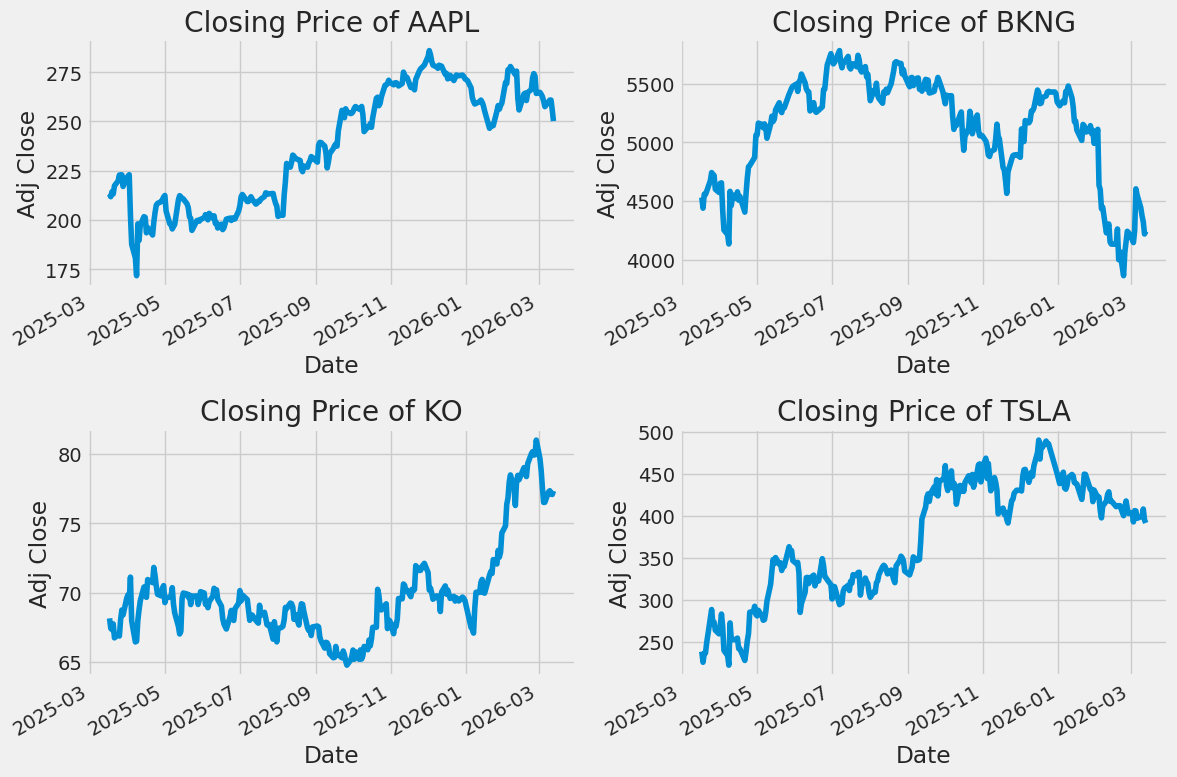

In [108]:
adj_close = data.xs('Adj Close', axis=1, level=0)

# Correct figure layout
plt.figure(figsize=(12, 8))
plt.subplots_adjust(top=0.95, bottom=0.1, hspace=0.3)  # top > bottom, values between 0-1

for i, stock in enumerate(adj_close.columns, 1):
    plt.subplot(2, 2, i)
    adj_close[stock].plot()
    plt.ylabel('Adj Close')
    plt.title(f'Closing Price of {stock}')

plt.tight_layout()
plt.show()

Sales Volumns

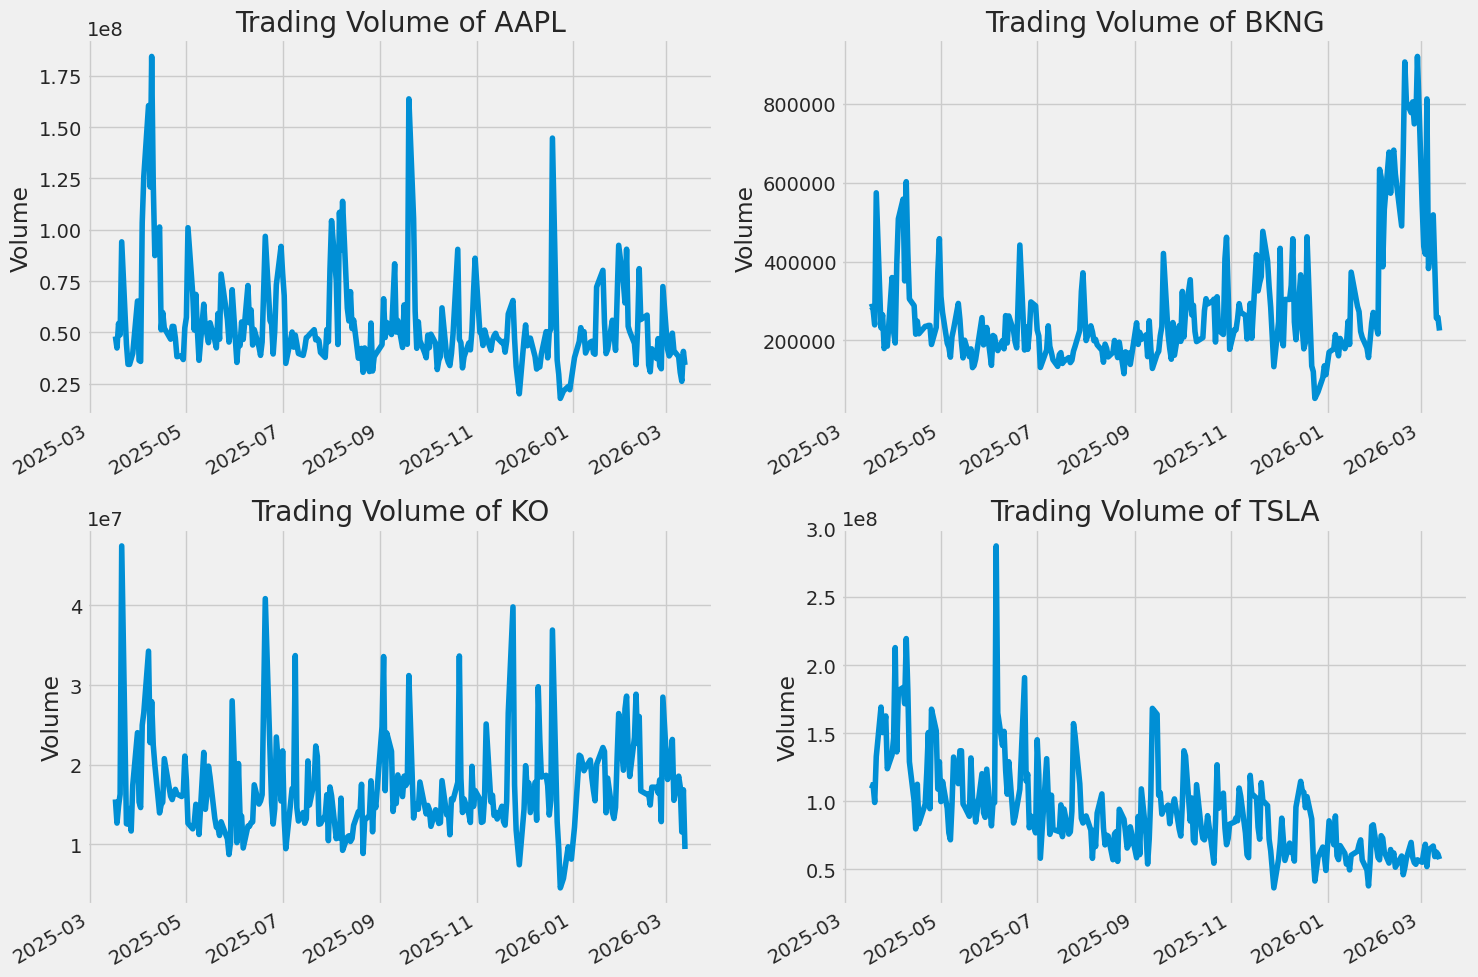

In [109]:
# Extract volume data
volumes = data["Volume"]
tech_list = volumes.columns.tolist()

plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(tech_list, 1):
    plt.subplot(2, 2, i)
    volumes[company].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Trading Volume of {company}")

plt.tight_layout()
plt.show()



## 2. What was the moving average of the various stocks?

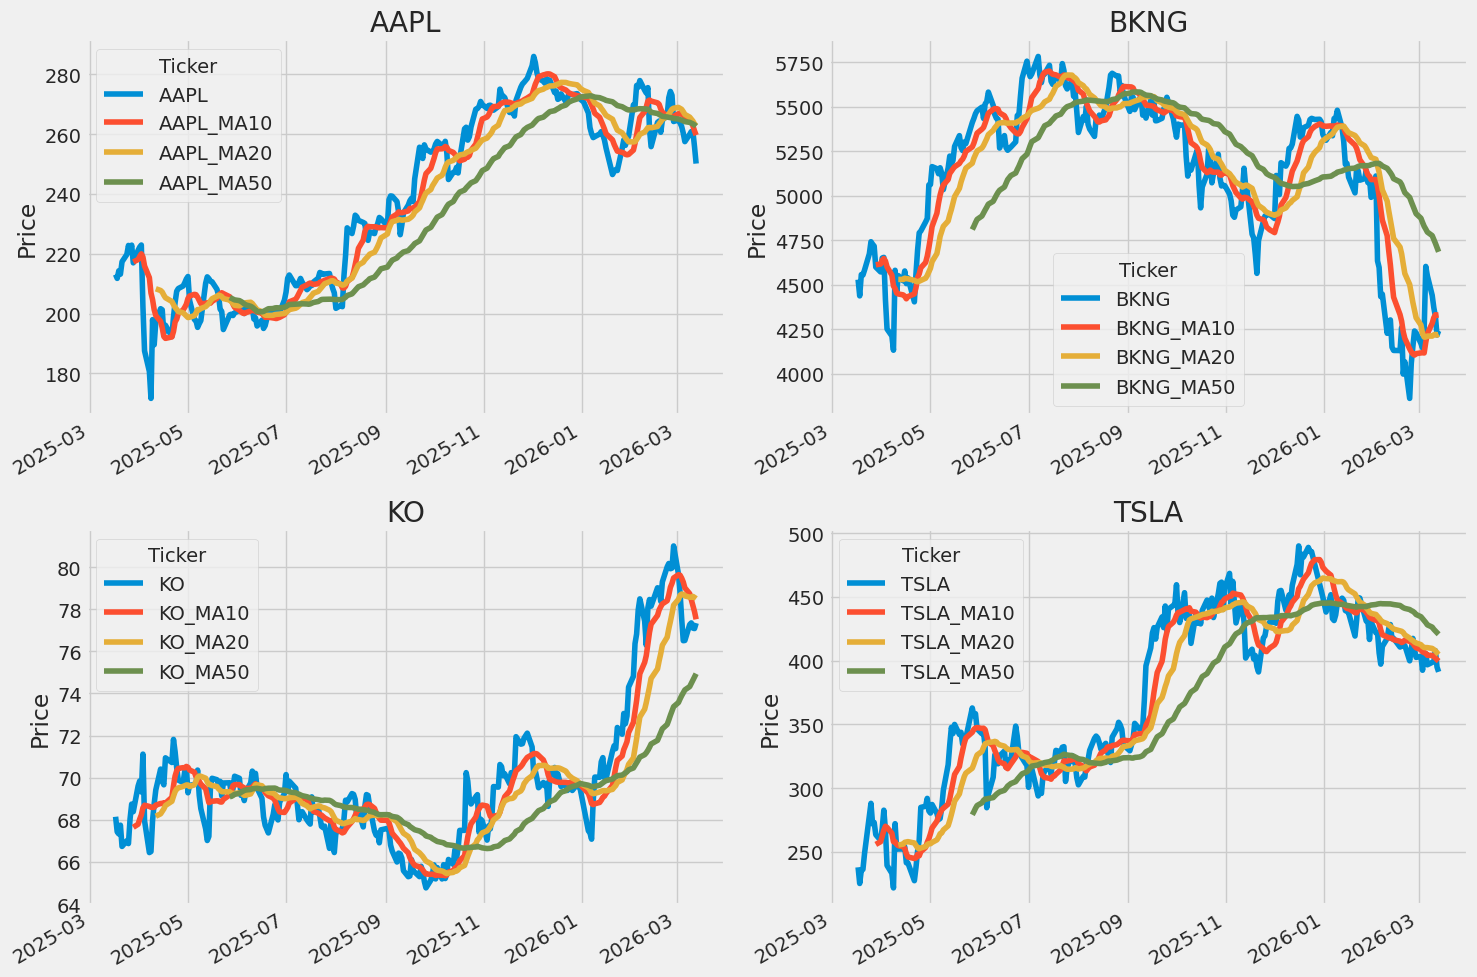

In [110]:
# Extract only the Adj Close prices
adj_close = data.xs('Adj Close', axis=1, level=0)

# List of companies
tech_list = adj_close.columns.tolist()
ma_days = [10, 20, 50]

# Create moving averages in a single DataFrame
ma_data = adj_close.copy()
for ma in ma_days:
    for stock in tech_list:
        ma_column = f"{stock}_MA{ma}"
        ma_data[ma_column] = adj_close[stock].rolling(ma).mean()

# Set up 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.subplots_adjust(top=0.92, hspace=0.3)

for i, stock in enumerate(tech_list):
    row = i // 2
    col = i % 2
    cols_to_plot = [stock] + [f"{stock}_MA{ma}" for ma in ma_days]
    ma_data[cols_to_plot].plot(ax=axes[row, col])
    axes[row, col].set_title(stock)
    axes[row, col].set_ylabel("Price")
    axes[row, col].set_xlabel(None)

plt.tight_layout()
plt.show()

## 3. What was the average daily return of the stock?

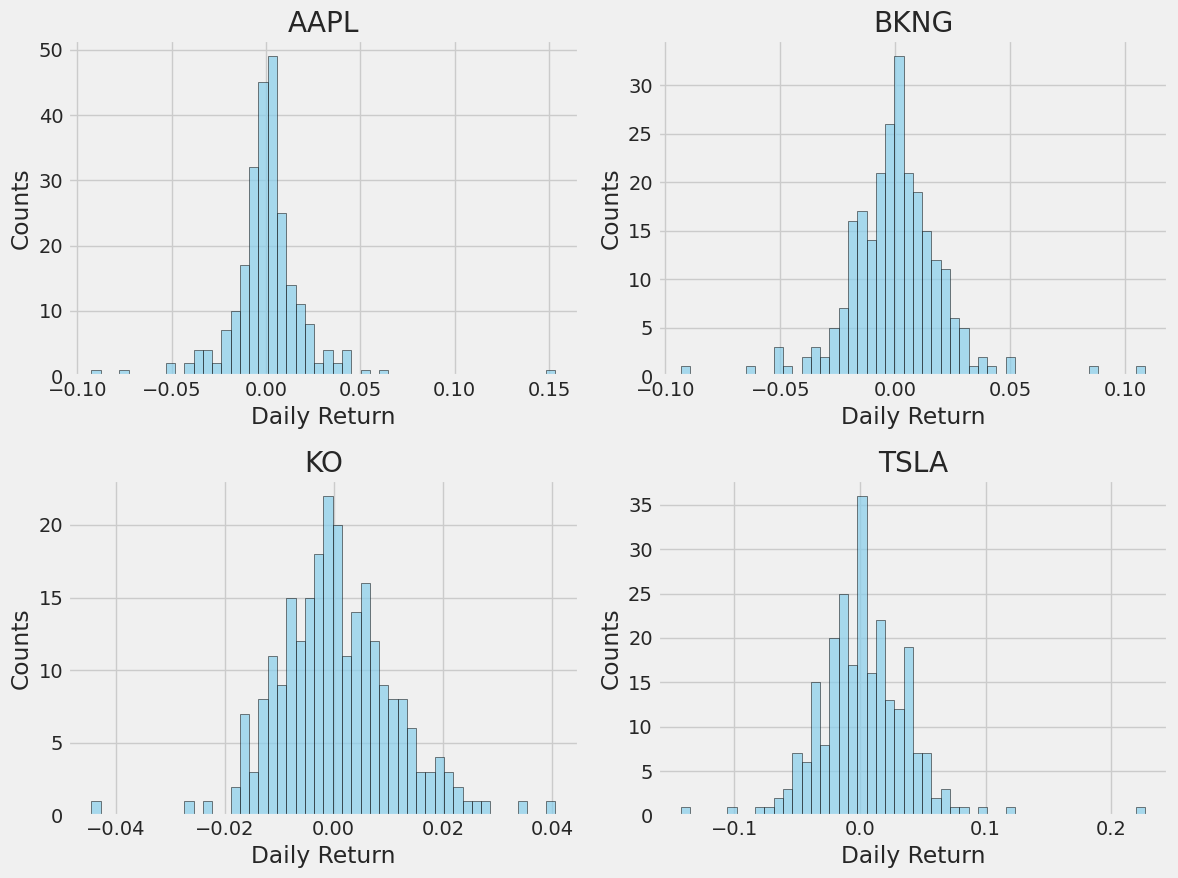

In [111]:
# Extract only the Adj Close prices
adj_close = data.xs('Adj Close', axis=1, level=0)

# Calculate daily returns
daily_returns = adj_close.pct_change()

# List of stocks
tech_list = adj_close.columns.tolist()

# Set up 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# Plot histogram for each stock
for i, stock in enumerate(tech_list):
    row = i // 2
    col = i % 2
    daily_returns[stock].hist(
        bins=50,
        ax=axes[row, col],
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )
    axes[row, col].set_title(f'{stock}')
    axes[row, col].set_xlabel('Daily Return')
    axes[row, col].set_ylabel('Counts')

plt.tight_layout()
plt.show()

This visualization tells you how the stock behaves day-to-day rather than how it trends over time. It’s a risk and volatility check.


## 4. What was the correlation between different stocks closing prices?

In [112]:
# Extract only Adjusted Close prices into a simple DataFrame
closing_df = data.xs('Adj Close', axis=1, level=0)

# Calculate daily returns
tech_rets = closing_df.pct_change()

# View first few rows
tech_rets.head(10)

Ticker,AAPL,BKNG,KO,TSLA
Date,,,,
2025-03-17,NaN,NaN,NaN,NaN
2025-03-18,-0.006122,-0.020134,-0.010553,-0.053359
2025-03-19,0.011989,0.026922,-0.001441,0.046824
2025-03-20,-0.005296,-0.000623,0.006207,0.001696
2025-03-21,0.019477,0.006152,-0.014919,0.052696
2025-03-24,0.011271,0.020025,0.004078,0.119336
2025-03-25,0.013682,0.014479,-0.002031,0.035023
2025-03-26,-0.009922,-0.002878,0.017585,-0.055806
2025-03-27,0.010473,-0.002384,0.010283,0.003933


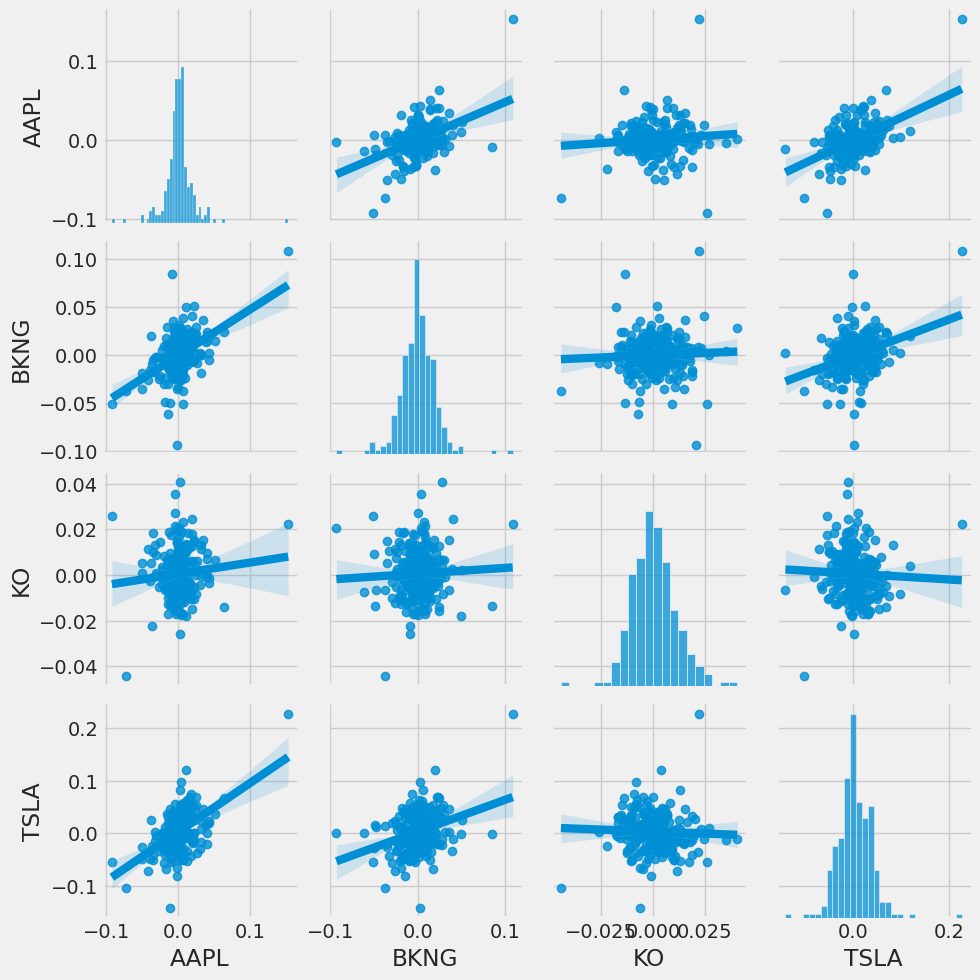

In [113]:
sns.pairplot(tech_rets, kind='reg')

Above we can see all the relationships on daily returns between all the stocks.


*  Strongest link: AAPL ↔ TSLA
→ both are large-cap "magnificent 7" style names, both very sensitive to the same macro factors (interest rates, growth expectations, tech sentiment, risk-on/risk-off days)
*  Medium link: BKNG ↔ TSLA (some shared growth/consumer vibe, but TSLA is outlier volatile)
*  Weakest link: Anything involving KO — it acts as the "odd one out." Coca-Cola is a classic low-beta, defensive name that doesn't swing much with tech/growth names. This makes it a natural diversifier in a portfolio heavy on AAPL/TSLA/BKNG.


Text(0.5, 1.0, 'Correlation of stock closing price')

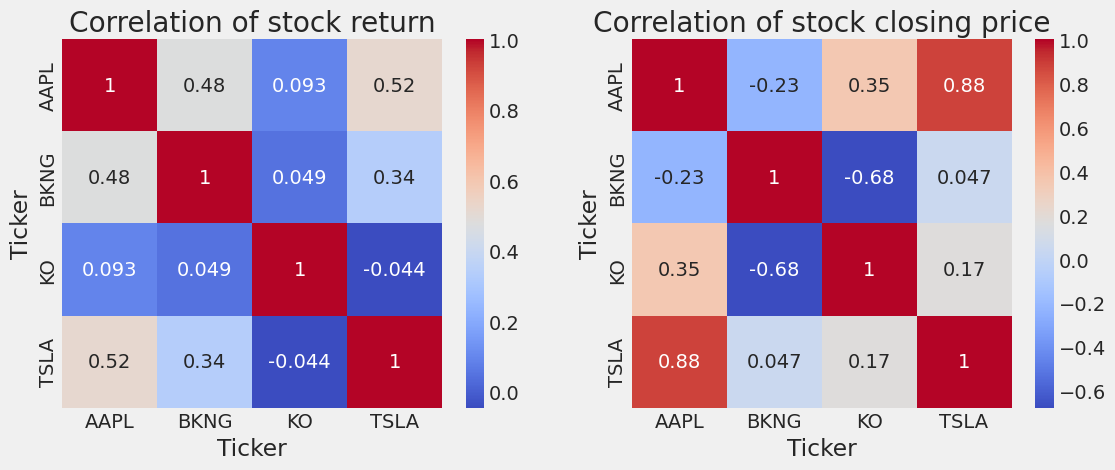

In [114]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of stock closing price')

For portfolio construction, risk management, or trading pairs/hedges → focus on the left matrix (returns). AAPL & TSLA move together reasonably (0.51), KO diversifies strongly.
The right matrix (prices) is mostly an artifact of long-term trends and less useful — it overstates relationships for trending stocks like AAPL/TSLA.

## 5. How much value do we put at risk by investing in a particular stock?

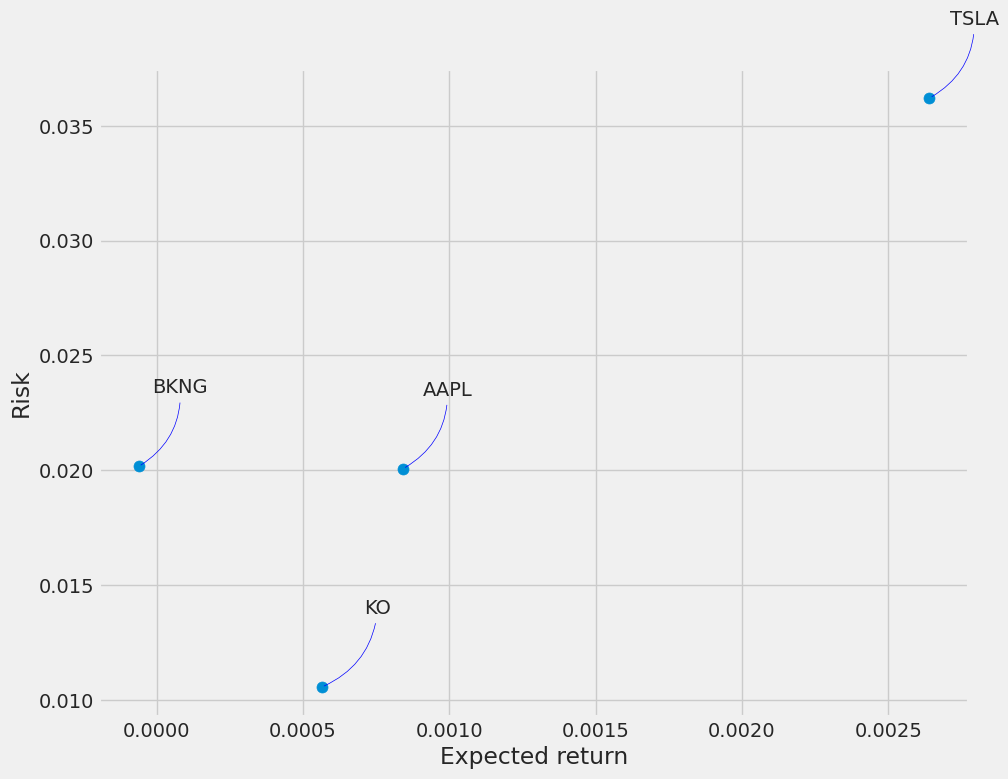

In [115]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))


*   KO is the risk-minimizing choice if capital preservation is priority (lowest volatility).

*   TSLA has delivered the highest average return historically in this sample — but you paid for it with much larger daily swings.
*   AAPL sits in a "sweet spot" — good return without going to TSLA-level extremes.
*   BKNG looks relatively unattractive here: similar risk to AAPL but much lower return → underperformed on a risk-adjusted basis in this period.




## 6.1 Predicting the closing price stock price of APPLE inc using LSTM:

In [116]:
# Download data
AAPL = yf.download('AAPL', start='2012-01-01', end=datetime.now(), auto_adjust=False)
AAPL

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2012-01-03,12.321687,14.686786,14.732143,14.607143,14.621429,302220800
2012-01-04,12.387905,14.765714,14.810000,14.617143,14.642857,260022000
2012-01-05,12.525435,14.929643,14.948214,14.738214,14.819643,271269600
2012-01-06,12.656373,15.085714,15.098214,14.972143,14.991786,318292800
2012-01-09,12.636299,15.061786,15.276786,15.048214,15.196429,394024400
...,...,...,...,...,...,...
2026-03-09,259.880005,259.880005,261.149994,253.679993,255.690002,38218500
2026-03-10,260.829987,260.829987,262.480011,256.950012,257.649994,30590800


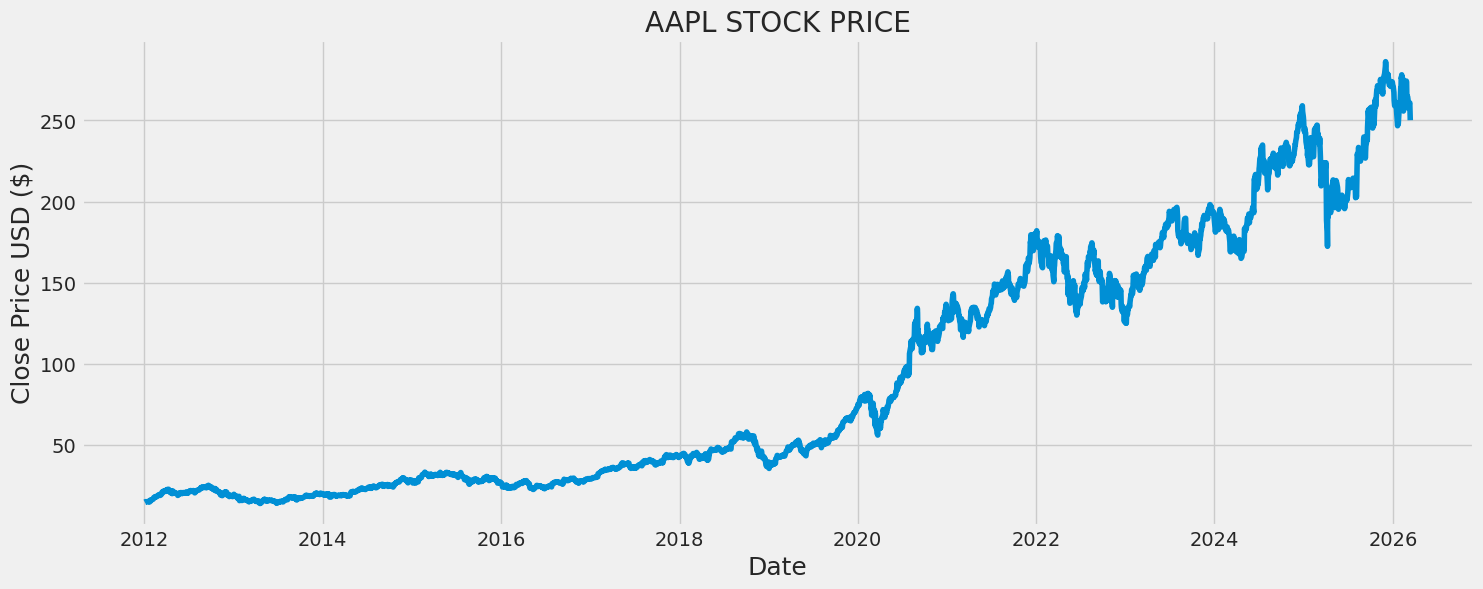

In [117]:
plt.figure(figsize=(16,6))
plt.title('AAPL STOCK PRICE')
plt.plot(AAPL['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [118]:
print(AAPL.columns)

MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [119]:
# Create a new dataframe with only the 'Close' column
df = AAPL[[('Close', 'AAPL')]]
log_df = np.log(df)

# Convert the dataframe to a numpy array
dataset = log_df.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * 0.9 ))

training_data_len

3213

In [120]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.01709427],
       [0.0188682 ],
       [0.02252247],
       ...,
       [0.9692642 ],
       [0.96279271],
       [0.95541235]])

In [121]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]

# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.01709427, 0.0188682 , 0.02252247, 0.02596448, 0.02543907,
       0.02662201, 0.02608199, 0.02517213, 0.02392879, 0.02776179,
       0.03118087, 0.03013022, 0.02431488, 0.02986703, 0.0244015 ,
       0.04444788, 0.04294023, 0.044907  , 0.04912013, 0.0516457 ,
       0.05143537, 0.05065816, 0.05395783, 0.05703236, 0.06048128,
       0.06597722, 0.07723326, 0.07740099, 0.08350221, 0.08798915,
       0.08023963, 0.08324526, 0.08318595, 0.09147246, 0.09030681,
       0.09246096, 0.09629713, 0.0984128 , 0.1044326 , 0.10875006,
       0.10998639, 0.11041773, 0.10303878, 0.10123357, 0.10150187,
       0.10847541, 0.11041166, 0.11453246, 0.12404784, 0.13633139,
       0.13406692, 0.13407256, 0.1427361 , 0.14540136, 0.14350606,
       0.14176559, 0.13994373, 0.14595799, 0.15002259, 0.15170958])]
[np.float64(0.14752470655740502)]

[array([0.01709427, 0.0188682 , 0.02252247, 0.02596448, 0.02543907,
       0.02662201, 0.02608199, 0.02517213, 0.02392879, 0.02776179,
       0.03118087, 0.03

In [122]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping

# Building the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # Monitor validation loss
    patience=10,          # Stop if no improvement for 10 epochs
    restore_best_weights=True  # Restore weights of best epoch
)

# Train the model with validation split and early stopping
history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,   # Use 10% of training data as validation
    callbacks=[early_stop]
)

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - loss: 0.0080 - val_loss: 0.0016
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - loss: 0.0015 - val_loss: 2.1395e-04
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0012 - val_loss: 1.2896e-04
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - loss: 0.0011 - val_loss: 5.5985e-04
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - loss: 9.7241e-04 - val_loss: 1.0631e-04
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 8.6472e-04 - val_loss: 4.8967e-04
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 7.1610e-04 - val_loss: 0.0011
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 6.9367e-04 - val_loss: 1.4396e-04
Epoch 9/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 6.0847e-04 - val_loss: 6.9054e-04
Epoch 10/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 5.7915e-04 - val_loss: 9.5487e-05
Epoch 11/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 5.9741e-04 - val_loss: 9.16

In [123]:
from sklearn.metrics import mean_squared_error

# Create the testing data set
test_data = scaled_data[training_data_len - 60: , :]

# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
# Reverse scaling
predictions = scaler.inverse_transform(predictions)
# Convert log prices back to real prices
predictions = np.exp(predictions)
y_test_actual = np.exp(y_test)

mse_lstm = mean_squared_error(y_test_actual.flatten(), predictions.flatten())
rmse_lstm = np.sqrt(mse_lstm)

print("LSTM RMSE:", rmse_lstm)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
LSTM RMSE: 8.292641984882845


In [124]:
# Creating a dataframe with only Close prices
data_plot = df.copy()
data_plot['Close'] = df['Close']
train = data_plot[:training_data_len]
valid = data_plot[training_data_len:].copy()
valid['Predictions'] = predictions.flatten()

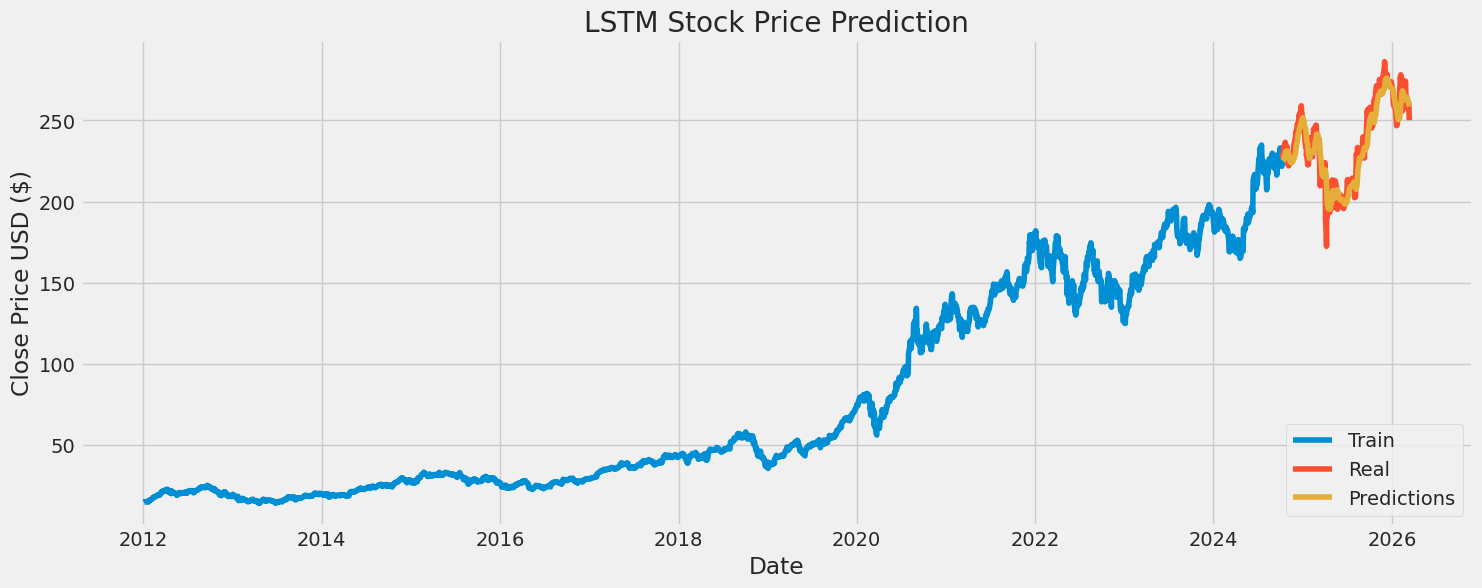

In [125]:
plt.figure(figsize=(16,6))

plt.title('LSTM Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')

plt.plot(train['Close'], label='Train')
plt.plot(valid['Close'], label='Real')
plt.plot(valid['Predictions'], label='Predictions')

plt.legend(loc='lower right')
plt.show()

In [126]:
valid

Price,Close,Predictions
Ticker,AAPL,
Date,,
2024-10-10,229.039993,225.232513
2024-10-11,227.550003,225.401093
2024-10-14,231.300003,225.562820
2024-10-15,233.850006,225.964890
2024-10-16,231.779999,226.661377
...,...,...
2026-03-09,259.880005,261.846039
2026-03-10,260.829987,260.840729


##  6.2 Predicting the closing price stock price of APPLE inc using ARIMA:

In [127]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [128]:
#Taking the AAPL df created in LSTM
log_df = np.log(df)
log_prices = np.log(df[('Close','AAPL')]) #Converting df to series

train_size= int(np.ceil( len(log_prices) * 0.9 ))

train_log = log_prices.iloc[:train_size]
test_log  = log_prices.iloc[train_size:]

# Dates for plotting
test_dates = log_prices.index[train_size:]

print(len(train_log))
print(len(test_log))


3213
356


In [129]:
# ADF test
result = adfuller(train_log.dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])
# If p > 0.05 → not stationary → you'll need differencing (d≥1 in ARIMA)

ADF Statistic: -0.26819525623422946
p-value: 0.9298896085435633


Since the pvalue is greater, the null hypothesis of "Non Stationarity" cannot be rejected, therefore differencing is necessary.

In [130]:
# Differencing by 1 time
log_diff_1 = train_log.diff().dropna()

In [131]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(log_diff_1)

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.4f}')

ADF Statistic: -18.25406990823856
p-value: 2.3392721086777846e-30
Critical Values:
	1%: -3.4324
	5%: -2.8624
	10%: -2.5673


ADF statistic is more negative than the critical values → Therefore now the process is stationary

In [132]:
!pip install pmdarima
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

auto_model = auto_arima(
    train_log,                     # ← original log prices (not differenced)
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    d=None,                        # ← let auto_arima find the right differencing
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    maxiter=50
)

print("Best order found:", auto_model.order)
print(auto_model.summary())

arima_fit = ARIMA(train_log, order=auto_model.order).fit()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-16761.092, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-16757.298, Time=0.29 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-16762.429, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-16762.573, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-16751.887, Time=0.13 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-16760.869, Time=0.39 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-16759.111, Time=1.46 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-16756.407, Time=0.20 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 3.729 seconds
Best order found: (0, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3213
Model:               SARIMAX(0, 1, 1)   Log Likelihood                8384.287
Date:                Sun, 15 Mar 2026   AIC                         -16

In [133]:
from statsmodels.tsa.arima.model import ARIMA

order=auto_model.order

history = train_log.values.tolist()
arima_preds_log = []

for t in range(len(test_log)):

    model = ARIMA(history, order=auto_model.order)
    model_fit = model.fit()

    forecast = model_fit.forecast()[0]
    arima_preds_log.append(forecast)

    history.append(test_log.iloc[t])

arima_predictions = np.exp(np.array(arima_preds_log))

actual_prices = np.exp(test_log.values)

mse_arima = mean_squared_error(actual_prices, arima_predictions)
rmse_arima = np.sqrt(mse_arima)
print("ARIMA RMSE:", rmse_arima)


ARIMA RMSE: 4.0939588070914095


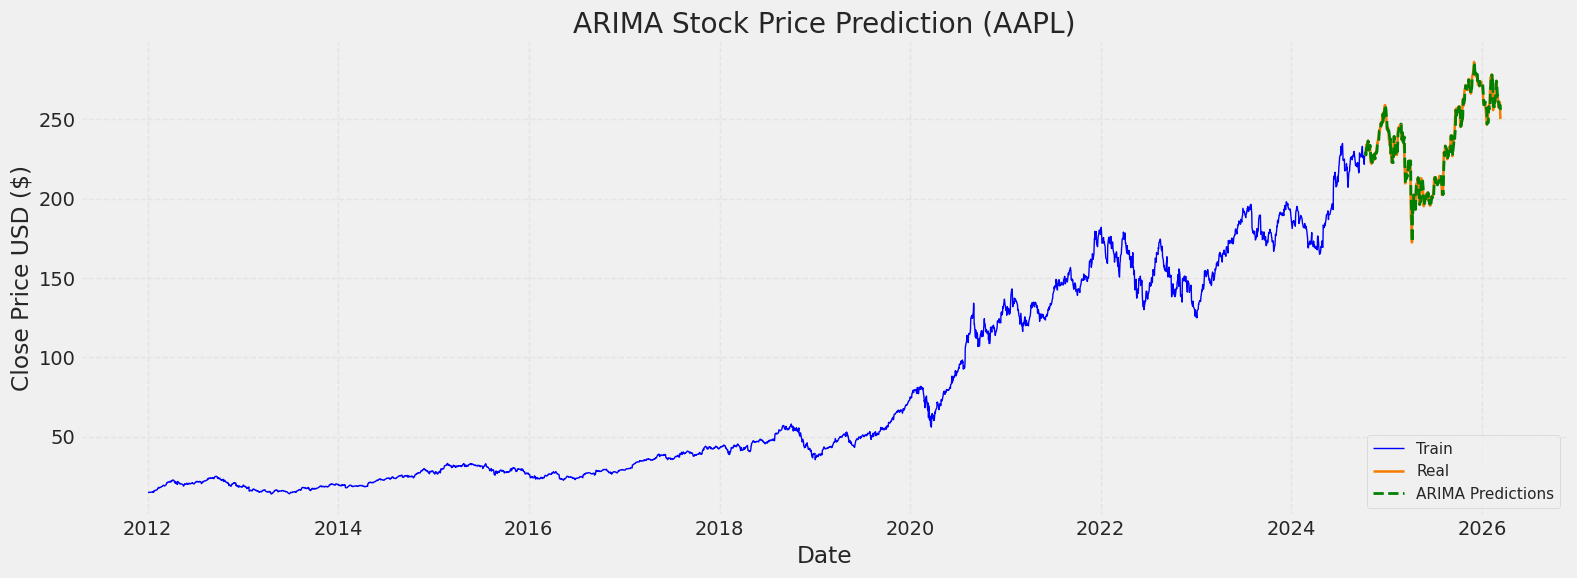

In [134]:
train_prices = np.exp(train_log)       # back to original scale
actual_test_prices = np.exp(test_log)  # back to original scale

train_plot = pd.Series(train_prices, index=train_log.index)
test_actual_plot = pd.Series(actual_test_prices, index=test_log.index)
test_pred_plot = pd.Series(arima_predictions, index=test_log.index)

# ─── Plot ─────────────────────────────────────────────────────────────
plt.figure(figsize=(16, 6))

plt.title('ARIMA Stock Price Prediction (AAPL)')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')

# Training period
plt.plot(train_plot.index, train_plot,
         label='Train', color='blue', linewidth=1.0)

# Test period — actual
plt.plot(test_actual_plot.index, test_actual_plot,
         label='Real', color='#f57c00', linewidth=1.8)

# Test period — ARIMA prediction
plt.plot(test_pred_plot.index, test_pred_plot,
         label='ARIMA Predictions', color='green', linewidth=2.0,
         linestyle='--')

plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### **Comparative Analysis of Stock Price Forecasting: LSTM vs. ARIMA**


In this project, we successfully implemented a financial data pipeline and compared two forecasting models for Apple’s stock price.
After training and validating both models on Apple’s stock data, the results were as follows:

    *   ARIMA RMSE: ~4.09

    *   LSTM RMSE: ~8.29

Key Findings:

In this specific study, the ARIMA model significantly outperformed the LSTM model. While LSTM is a powerful tool for complex patterns, the superior performance of ARIMA suggests that for this specific timeframe, the stock's movement was more closely tied to its immediate historical trends and mean-reverting properties.


Lessons Learned:


*   Model Simplicity: This result highlights a common phenomenon in quantitative finance—sometimes "simpler" statistical models are more robust against market noise than complex neural networks.

*   Forecasting Reality: Stock prices are often "random walks," and the ARIMA model’s focus on differencing and moving averages provided a more accurate "fit" for the validation data.


This project successfully demonstrates a full Data Science workflow: from data acquisition and risk modeling to a rigorous comparison of Machine Learning vs. Statistical Inference.